### Analysis of results

In [1]:
def default_params(): 
    return {
        'aligments_base' : '/workspaces/CodeSmells/data/extension/mitigation/alignments/base/M1_q_none/aligned_smells.json',
        'aligments_prompted' : '/workspaces/CodeSmells/data/extension/mitigation/alignments/prompted/M1_q_none/aligned_smells.json',
        'score': 'code_smell_actual_prob_median',
    }
params = default_params()


### Imports

In [2]:
import pandas as pd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### Dataset Loading

In [4]:
aligments_base_df = pd.read_json(params['aligments_base'])
aligments_prompted_df = pd.read_json(params['aligments_prompted'])

In [5]:
aligments_prompted_df.columns

Index(['id', 'commit_id', 'repo', 'path', 'file_name', 'fun_name',
       'commit_message', 'code', 'url', 'language', 'ast_errors',
       'n_ast_errors', 'ast_levels', 'n_whitespaces', 'n_words', 'vocab_size',
       'complexity', 'nloc', 'token_counts', 'n_ast_nodes', 'n_identifiers',
       's_msg_id', 's_line', 's_column', 's_end_line', 's_end_column',
       's_code', 'category', 'input_lenght', 'prompt_id', 'prompt',
       'original_code', 'input_ids', 'prompt_ids', 'max_prob', 'min_prob',
       'actual_prob', 'loss', 'code_smell_pos', 'code_smell_actual_logits',
       'code_smell_max_logits', 'code_smell_min_logits',
       'code_smell_actual_prob_median', 'code_smell_max_prob_median',
       'code_smell_min_prob_median', 'code_smell_actual_prob_mean',
       'code_smell_max_prob_mean', 'code_smell_min_prob_mean',
       'code_smell_psc_entropy', 'code_smell_psc_relative'],
      dtype='object')

### Extract Distributions

In [6]:
aligments_base_df['s_msg_id'].unique()

array(['C0304', 'W0611', 'W0719'], dtype=object)

In [7]:
def extract_distributions(df, score, type):
    distribution_df = df[[params['score'], 's_msg_id']].copy()
    distribution_df = distribution_df.rename(columns={score: 'value'})
    distribution_df['type'] = type
    return distribution_df

In [8]:
base_distribuion_df = extract_distributions(aligments_base_df, params['score'], 'base')
prompted_distribuion_df = extract_distributions(aligments_prompted_df, params['score'], 'prompted')
## merge distributions
distribution_df = pd.concat([base_distribuion_df, prompted_distribuion_df], ignore_index=True)

In [9]:
# Remove outliers from distribution_df per s_msg_id using IQR
def remove_outliers_iqr(group):
    Q1 = group['value'].quantile(0.25)
    Q3 = group['value'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group['value'] >= lower_bound) & (group['value'] <= upper_bound)]

distribution_df = distribution_df.groupby('s_msg_id').apply(remove_outliers_iqr).reset_index(drop=True)

/tmp/ipykernel_61428/2453047620.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  distribution_df = distribution_df.groupby('s_msg_id').apply(remove_outliers_iqr).reset_index(drop=True)


### Visualization

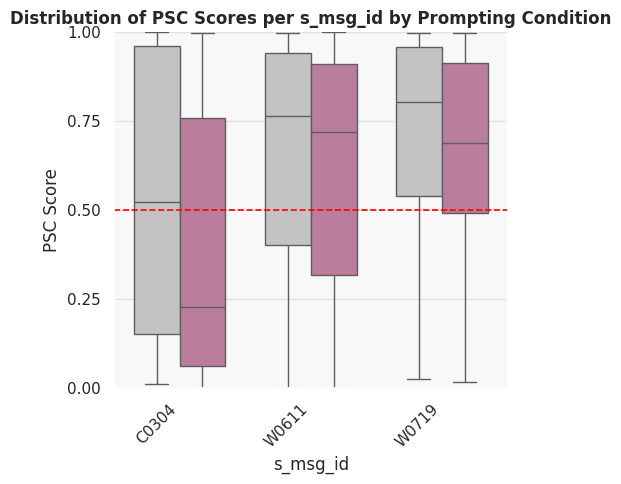

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the plot style and background
sns.set(style="whitegrid", font_scale=1.0, rc={
    "axes.facecolor": "#f8f8f8",
    "axes.edgecolor": "white",
    "grid.color": "#e1e1e1",
    "axes.grid": True,
})

# Custom color palette
custom_palette = {"base": "#c4c3c4", "prompted": "#c4739c"}

# Ensure s_msg_id is treated as a categorical variable and has a compact order
distribution_df['s_msg_id'] = distribution_df['s_msg_id'].astype(str)

plt.figure(figsize=(5, 5))
ax = sns.boxplot(
    x="s_msg_id",
    y="value",
    hue="type",
    data=distribution_df,
    palette=custom_palette,
    width=0.7,
    fliersize=3,
    linewidth=1.0,
)

# Add horizontal line for threshold
plt.axhline(y=0.5, color="red", linestyle="--", linewidth=1.2)

# --- Add median labels for each box ---
# Medians by (s_msg_id, type)
medians = (
    distribution_df
    .groupby(["s_msg_id", "type"])["value"]
    .median()
    .reset_index()
)

# Categorical levels and hue order
x_levels = list(distribution_df['s_msg_id'].unique())
hue_levels = ["base", "prompted"]

# Match seaborn's internal offset computation: width * (k / (n_hue + 1))
n_hue = len(hue_levels)
width = 0.7
base_offset = width / (n_hue + 1)

for _, row in medians.iterrows():
    x_cat = row['s_msg_id']
    hue = row['type']
    median_val = row['value']
    # Base x position of the category
    cat_index = x_levels.index(x_cat)
    x_center = cat_index

    # Offset for hue
    hue_index = hue_levels.index(hue)
    offset = (hue_index - (n_hue - 1) / 2) * base_offset
    x_pos = x_center + offset

    # Draw a small horizontal tick at the median and a text label
    ax.plot([x_pos - 0.05, x_pos + 0.05], [median_val, median_val],
            color='black', linewidth=1.0)
    ax.text(x_pos, median_val + 0.02, f"{median_val:.2f}",
            ha='center', va='bottom', fontsize=8, color='black')

# Axis labels and title
plt.title("Distribution of PSC Scores per s_msg_id by Prompting Condition", fontsize=12, weight='semibold')
plt.xlabel("s_msg_id")
plt.ylabel("PSC Score")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Remove top and right spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Hide legend
ax.legend_.remove()

# Set y scale and ticks
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

plt.tight_layout()
plt.show()
